# Single-Fidelity Triangular Maps Tutorial

This notebook is a compact, end-to-end introduction to the single-fidelity `TriangularMap` API. We learn a monotone lower-triangular map that pushes a two-dimensional banana target density $\pi_0$ to a standard Gaussian reference density $\eta$.

We construct and train the map twice---once from a total order and once from explicit multi-index sets---then use the total-order fit, denoted $\widehat{\boldsymbol{S}}^{\mathrm{SF}}$, for pushforwards, inverse sampling, conditional sampling, and density evaluation.

## Paper notation used in this notebook

This is the single-fidelity baseline corresponding to Section 3 and the
paper's $\widehat{\boldsymbol{S}}^{\mathrm{SF}}$ comparison map. We use $d=2$, target
$\pi_0$, dataset $\mathcal X_0=\{x_0^{(j)}\}_{j=1}^{N_0}$, and reference
$\eta=\mathcal N(0,I)$. The executable names `X_0`, `N_0`, `S_hat_SF`, and
`S_hat_SF_MI` are ASCII spellings of those symbols. Equations (3.1)--(3.8)
describe the triangular map, KL objective, and monotonic parameterization
used by the public `TriangularMap` API below.

## 1. The analytic banana example

Let $Z=(Z_1,Z_2)\sim\eta=\mathcal N(0,I)$ and define the target samples by

$$
X_1=Z_1,\qquad X_2=Z_2+b(Z_1^2-1),\qquad b=0.5.
$$

This construction gives rise to a unique monotone lower-triangular map $\boldsymbol{S}$ (Knothe--Rosenblatt rearrangement) that pushes the target to the reference,

$$
\boldsymbol{S}(x)=
\begin{bmatrix}x_1\\x_2-b(x_1^2-1)\end{bmatrix},
\qquad
\boldsymbol{S}^{-1}(z)=
\begin{bmatrix}z_1\\z_2+b(z_1^2-1)\end{bmatrix}.
$$

Its Jacobian determinant is one, so $\log\pi(x)=\log\eta(\boldsymbol{S}(x))$. The ordering is useful because the exact conditional is also known:

$$X_2\mid X_1=a\sim\mathcal N\!\left(b(a^2-1),1\right).$$

We call the learned forward map $\widehat{\boldsymbol{S}}^{\mathrm{SF}}$.

In [1]:
import time

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np

from mftt import MapParams, OptimizationParams, Reference, TriangularMap

SEED = 101
rng = np.random.default_rng(SEED)
BEND = 0.5  # curvature of banana
INPUT_DIM = 2

TARGET_COLOR = "#E76F51"
REFERENCE_COLOR = "#457B9D"
LEARNED_COLOR = "#2A9D8F"
SPARSE_COLOR = "#8E5EA2"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "font.size": 10,
})


## 2. Sampling and density helpers

All helpers below work on batches with shape `(n_samples, 2)`. They let us compare the learned map with the exact distribution without relying on any extra package.

In [2]:
def banana_sample(n_samples, rng, bend=BEND):
    """Draw samples from pi by applying the exact inverse S^{-1}."""
    z = rng.standard_normal((n_samples, 2))
    return S_0_inverse(z, bend=bend)


def S_0(x, bend=BEND):
    """Analytic Knothe--Rosenblatt map S: pi -> eta."""
    x = np.asarray(x, dtype=float)
    z = x.copy()
    z[:, 1] = x[:, 1] - bend * (x[:, 0] ** 2 - 1.0)
    return z

def S_0_inverse(z, bend=BEND):
    """Analytic inverse S^{-1}: eta -> pi."""
    z = np.asarray(z, dtype=float)
    x = z.copy()
    x[:, 1] = z[:, 1] + bend * (z[:, 0] ** 2 - 1.0)
    return x

def standard_normal_logpdf(z):
    z = np.asarray(z, dtype=float)
    return -0.5 * np.sum(z * z, axis=1) - np.log(2.0 * np.pi)

def banana_logpdf(x, bend=BEND):
    return standard_normal_logpdf(S_0(x, bend=bend))

def normal_pdf_1d(values, mean=0.0, std=1.0):
    values = np.asarray(values, dtype=float)
    scaled = (values - mean) / std
    return np.exp(-0.5 * scaled * scaled) / (np.sqrt(2.0 * np.pi) * std)

def make_grid(x_limits, y_limits, n=220):
    x1 = np.linspace(*x_limits, n)
    x2 = np.linspace(*y_limits, n)
    xx, yy = np.meshgrid(x1, x2)
    return xx, yy, np.column_stack((xx.ravel(), yy.ravel()))

def style_joint_axis(ax, x_label=r"$x_1$", y_label=r"$x_2$", limits=(-4.0, 4.0, -4.5, 4.5)):
    ax.set(xlabel=x_label, ylabel=y_label, xlim=limits[:2], ylim=limits[2:])
    ax.set_aspect("equal", adjustable="box")

# Verify the analytic pair before learning anything.
analytic_probe = banana_sample(128, rng)
assert np.allclose(S_0_inverse(S_0(analytic_probe)), analytic_probe)


## 3. Target and reference at a glance

The contours plots show the true target and reference densities. The overlayed scatter plots show independent samples from these densities. 

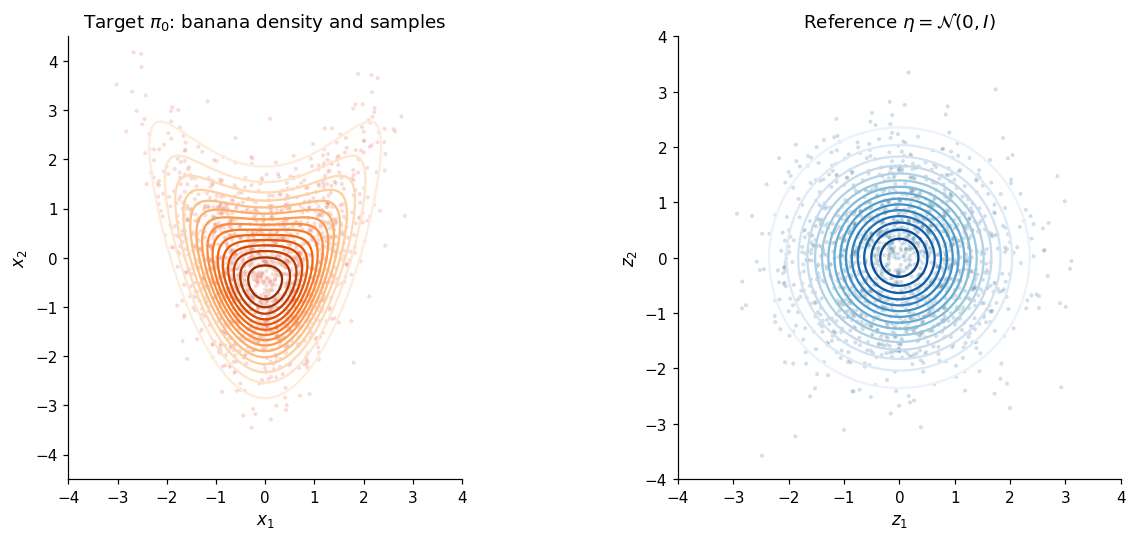

In [3]:
# Define number of training, testing, and display points
N_0 = 10000
N_test = 6000
N_display = 1500

X_0 = banana_sample(N_0, rng)
x_0_test = banana_sample(N_test, rng)
z_reference_display = rng.standard_normal((N_display, INPUT_DIM))

x_xx, x_yy, x_grid = make_grid((-4.0, 4.0), (-4.5, 4.5))
z_xx, z_yy, z_grid = make_grid((-4.0, 4.0), (-4.0, 4.0))
true_pi_0_density = np.exp(banana_logpdf(x_grid)).reshape(x_xx.shape)
reference_density = np.exp(standard_normal_logpdf(z_grid)).reshape(z_xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
axes[0].contour(x_xx, x_yy, true_pi_0_density, levels=18, cmap="Oranges")
axes[0].scatter(X_0[:N_display, 0], X_0[:N_display, 1], s=7, alpha=0.24, color=TARGET_COLOR, edgecolors="none")
axes[0].set_title(r"Target $\pi_0$: banana density and samples")
style_joint_axis(axes[0])

axes[1].contour(z_xx, z_yy, reference_density, levels=18, cmap="Blues")
axes[1].scatter(z_reference_display[:, 0], z_reference_display[:, 1], s=7, alpha=0.24, color=REFERENCE_COLOR, edgecolors="none")
axes[1].set_title(r"Reference $\eta=\mathcal{N}(0,I)$")
style_joint_axis(axes[1], r"$z_1$", r"$z_2$", (-4.0, 4.0, -4.0, 4.0))
plt.show()


## 4. Construct two maps

Map components are parameterized by multivariate Hermite functions. These can be specified through a total order or through an explicit list of multi-indices.
We exercise both map construction methods below. The total-order construction uses total order 2, and the explicit construction specifies per-component multi-indices:

- Component 1 uses `[(0,), (1,)]`
- Component 2 uses `[(0, 0), (0, 1), (2, 0)]`

We require all components to be at least total order 1, enabling consistent identity initialization.

In [4]:
# Specify reference density
reference = Reference.standard_normal(INPUT_DIM)

# Specify optimization parameters: supports scipy BFGS and L-BFGS-B
optimization = OptimizationParams(
    optimizer="BFGS",
    reg_cst=1e-10,
    gtol=1e-8,
    maxiter=200,
)

# Primary learned map: \widehat{\boldsymbol{S}}^{\mathrm{SF}}, specified only by total order.
total_order_params = MapParams(total_order=2, optimization=optimization)
S_hat_SF = TriangularMap(X_0, total_order_params, reference=reference)

# Alternative learned map: \widehat{\boldsymbol{S}}^{\mathrm{SF}}_{MI}, specified by multi-index sets.
explicit_multi_index_sets = [
    [(0,), (1,)],
    [(0, 0), (0, 1), (2, 0)],
]
S_hat_SF_MI = TriangularMap.from_multi_index_sets(
    X_0,
    explicit_multi_index_sets,
    reference=reference,
    optimization=optimization,
)


# You can get a human readable description of the maps through the print command:
print(S_hat_SF)
print(S_hat_SF_MI)


TriangularMap(family=single_fidelity, input_dim=2, basis=total_order(2), components=2, samples=10000, reference=StandardNormal(dim=2))
TriangularMap(family=single_fidelity, input_dim=2, basis=explicit_multi_indices, component_terms=[2, 3], component_max_degrees=[1, 2], components=2, samples=10000, reference=StandardNormal(dim=2))


## 5. Training the maps

Map training is accomplished via `TriangularMap.train()`. 

In [5]:
# Train total-order map
start = time.perf_counter()
S_hat_SF.train(verbose=True)
total_order_seconds = time.perf_counter() - start

# Train explicit multi-index map
start = time.perf_counter()
S_hat_SF_MI.train(verbose=True)
explicit_seconds = time.perf_counter() - start

print("Total-order map coefficients:", S_hat_SF.coeffs.size)
print("Explicit multi-index map coefficients:", S_hat_SF_MI.coeffs.size)
print(f"Total-order training time: {total_order_seconds:.2f} s")
print(f"Explicit multi-index training time: {explicit_seconds:.2f} s")
print("\nTotal-order optimizer diagnostics:")
print(S_hat_SF.optimization_diagnostics())
print("\nExplicit multi-index optimizer diagnostics:")
print(S_hat_SF_MI.optimization_diagnostics())


Completed training component 1/2.


Completed training component 2/2.
Completed training component 1/2.
Completed training component 2/2.
Total-order map coefficients: 9
Explicit multi-index map coefficients: 5
Total-order training time: 0.71 s
Explicit multi-index training time: 0.18 s

Total-order optimizer diagnostics:
{'components': [{'success': True, 'status': 0, 'message': 'Optimization terminated successfully.', 'nit': 13, 'nfev': 16, 'njev': 16, 'fun': 0.49966777202495444, 'grad_norm': 3.4644990610850336e-09, 'optimizer': 'BFGS', 'gtol': 1e-08, 'maxiter': 200, 'reg_cst': 1e-10}, {'success': True, 'status': 0, 'message': 'Optimization terminated successfully.', 'nit': 40, 'nfev': 44, 'njev': 44, 'fun': 0.2999724851332188, 'grad_norm': 4.474511449152462e-10, 'optimizer': 'BFGS', 'gtol': 1e-08, 'maxiter': 200, 'reg_cst': 1e-10}], 'aao': None}

Explicit multi-index optimizer diagnostics:
{'components': [{'success': True, 'status': 0, 'message': 'Optimization terminated successfully.', 'nit': 0, 'nfev': 1, 'njev': 1, 

## 5. Compare the learned pushforwards

`evaluate(x)` computes the learned forward map. The exact $\boldsymbol{S}$, the total-order $\widehat{\boldsymbol{S}}^{\mathrm{SF}}$, and the sparse $\widehat{\boldsymbol{S}}^{\mathrm{SF}}_{MI}$ should all turn held-out banana samples into samples close to $\eta$.

The total-order model remains the primary $\widehat{\boldsymbol{S}}^{\mathrm{SF}}$ below.

### $\widehat{\boldsymbol{S}}^{\mathrm{SF}}$ (total order)

  coefficients: 9, training: 0.71 s
  RMSE against exact S: 0.0512
  pushed mean: [0.01  0.039]
  pushed covariance:
 [[0.975 0.009]
 [0.009 1.   ]]
  max round-trip error: 1.16e-08


### $\widehat{\boldsymbol{S}}^{\mathrm{SF}}_{MI}$ (explicit)

  coefficients: 5, training: 0.18 s
  RMSE against exact S: 0.0530
  pushed mean: [0.01  0.039]
  pushed covariance:
 [[0.973 0.004]
 [0.004 1.001]]
  max round-trip error: 1.11e-15


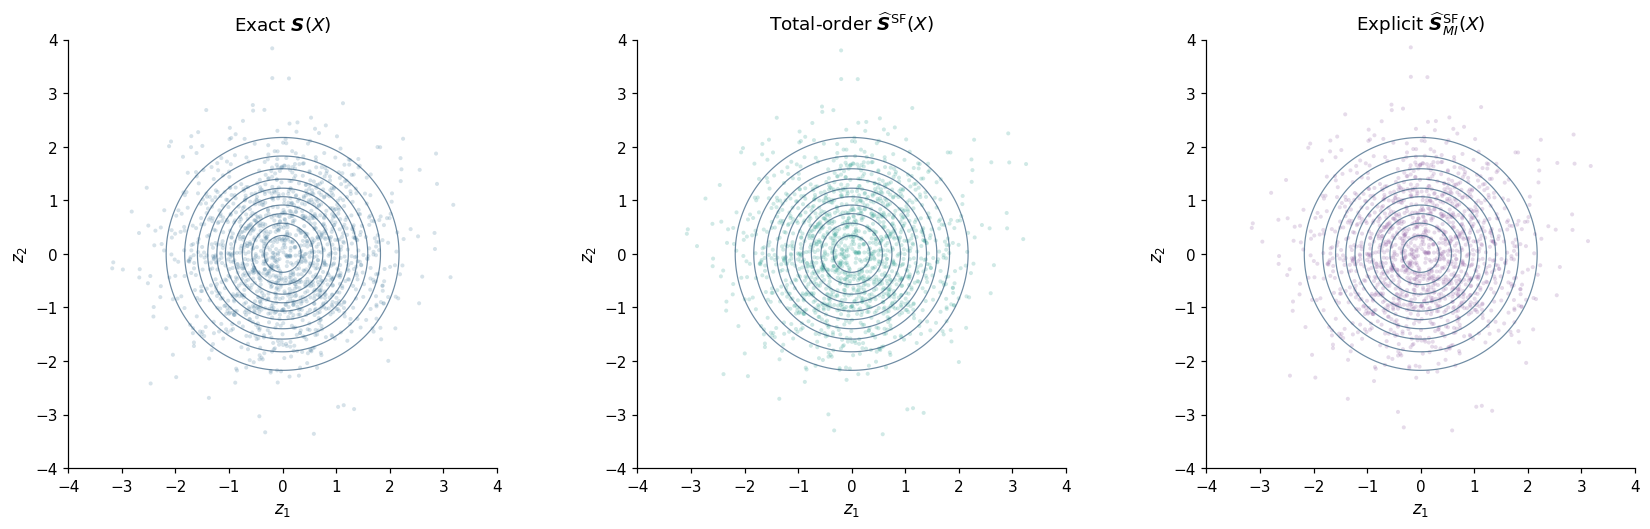

In [6]:
def map_summary(name, model, elapsed_seconds):
    z_hat = model.evaluate(x_0_test)
    exact_z = S_0(x_0_test)
    recovered = model.inverse(z_hat[:512])
    round_trip_error = np.max(np.abs(recovered - x_0_test[:512]))
    assert round_trip_error < 1e-6
    return {
        "name": name,
        "coefficients": model.coeffs.size,
        "seconds": elapsed_seconds,
        "S_rmse": float(np.sqrt(np.mean((z_hat - exact_z) ** 2))),
        "pushforward_mean": z_hat.mean(axis=0),
        "pushforward_covariance": np.cov(z_hat, rowvar=False),
        "round_trip_error": float(round_trip_error),
        "z_hat": z_hat,
    }

summaries = [
    map_summary(r"$\widehat{\boldsymbol{S}}^{\mathrm{SF}}$ (total order)", S_hat_SF, total_order_seconds),
    map_summary(r"$\widehat{\boldsymbol{S}}^{\mathrm{SF}}_{MI}$ (explicit)", S_hat_SF_MI, explicit_seconds),
]

for result in summaries:
    display(Markdown(f"### {result['name']}"))
    print(f"  coefficients: {result['coefficients']}, training: {result['seconds']:.2f} s")
    print(f"  RMSE against exact S: {result['S_rmse']:.4f}")
    print("  pushed mean:", np.array2string(result["pushforward_mean"], precision=3))
    print("  pushed covariance:\n", np.array2string(result["pushforward_covariance"], precision=3))
    print(f"  max round-trip error: {result['round_trip_error']:.2e}")

exact_pushforward = S_0(x_0_test[:N_display])
total_pushforward = summaries[0]["z_hat"][:N_display]
explicit_pushforward = summaries[1]["z_hat"][:N_display]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.7), constrained_layout=True)
for ax, pushed, color, title in zip(
    axes,
    [exact_pushforward, total_pushforward, explicit_pushforward],
    [REFERENCE_COLOR, LEARNED_COLOR, SPARSE_COLOR],
    [r"Exact $\boldsymbol{S}(X)$", r"Total-order $\widehat{\boldsymbol{S}}^{\mathrm{SF}}(X)$", r"Explicit $\widehat{\boldsymbol{S}}^{\mathrm{SF}}_{MI}(X)$"],
):
    ax.contour(z_xx, z_yy, reference_density, levels=10, colors="#315B7D", linewidths=0.8, alpha=0.7)
    ax.scatter(pushed[:, 0], pushed[:, 1], s=7, alpha=0.22, color=color, edgecolors="none")
    ax.set_title(title)
    style_joint_axis(ax, r"$z_1$", r"$z_2$", (-4.0, 4.0, -4.0, 4.0))
plt.show()


## 6. Unconditional target sampling via $(\widehat{\boldsymbol{S}}^{\mathrm{SF}})^{-1}$

To draw from the learned target, first draw $z\sim\eta$ and then apply `inverse(z)`, which computes $(\widehat{\boldsymbol{S}}^{\mathrm{SF}})^{-1}(z)$. `sample(...)` is a convenience wrapper that performs the same two steps.

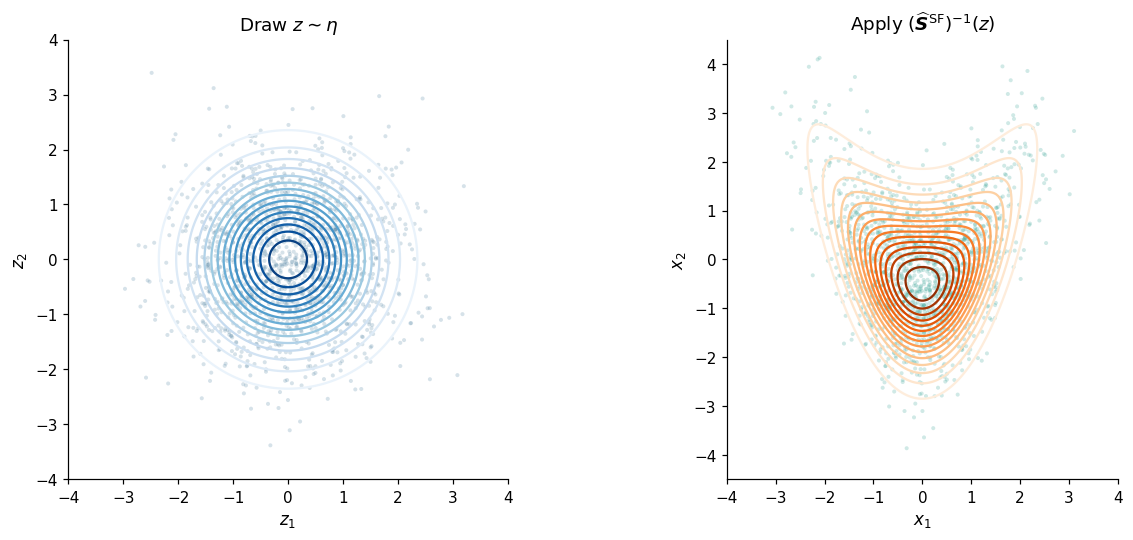

In [7]:
n_generate = 5000
sampling_seed = 404
sampling_rng = np.random.default_rng(sampling_seed)
z_draws = sampling_rng.standard_normal((n_generate, INPUT_DIM))

x_draws_from_inverse = S_hat_SF.inverse(z_draws)
x_draws_from_sample = S_hat_SF.sample(n_generate, random_state=sampling_seed)
assert np.allclose(x_draws_from_inverse, x_draws_from_sample)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
axes[0].contour(z_xx, z_yy, reference_density, levels=18, cmap="Blues")
axes[0].scatter(z_draws[:N_display, 0], z_draws[:N_display, 1], s=7, alpha=0.22, color=REFERENCE_COLOR, edgecolors="none")
axes[0].set_title(r"Draw $z\sim\eta$")
style_joint_axis(axes[0], r"$z_1$", r"$z_2$", (-4.0, 4.0, -4.0, 4.0))

axes[1].contour(x_xx, x_yy, true_pi_0_density, levels=18, cmap="Oranges")
axes[1].scatter(x_draws_from_inverse[:N_display, 0], x_draws_from_inverse[:N_display, 1], s=7, alpha=0.22, color=LEARNED_COLOR, edgecolors="none")
axes[1].set_title(r"Apply $(\widehat{\boldsymbol{S}}^{\mathrm{SF}})^{-1}(z)$")
style_joint_axis(axes[1])
plt.show()


## 7. Conditional sampling and conditional density

For a lower-triangular map in this variable order, we can fix a leading prefix. Here we condition on $X_1=0.5$ and sample $X_2$. The library therefore uses `fixed_indices=[0]`.

The same learned map provides the conditional density through `conditional_pullback_pdf(x, fixed_indices=[0])`.

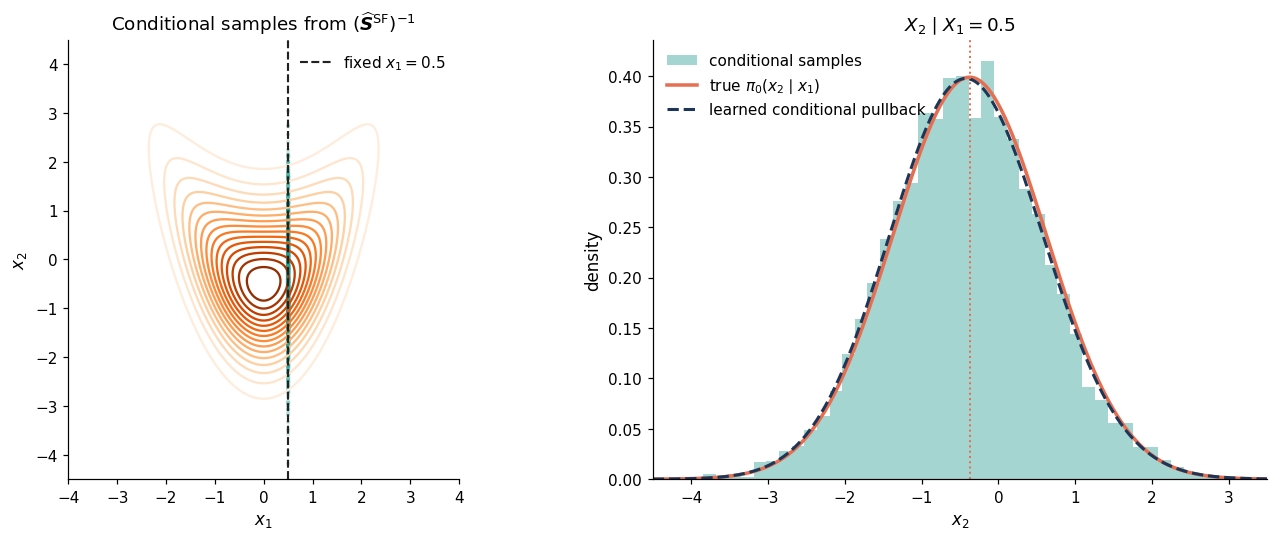

In [8]:

conditioned_x1 = 0.5
n_conditional = 5000
conditional_samples = S_hat_SF.conditional_sample(
    n_conditional,
    fixed_indices=[0],
    fixed_values=np.array([conditioned_x1]),
    random_state=808,
)
assert np.allclose(conditional_samples[:, 0], conditioned_x1)

x2_conditional_grid = np.linspace(-4.5, 3.5, 500)
conditional_grid = np.column_stack((np.full_like(x2_conditional_grid, conditioned_x1), x2_conditional_grid))
true_conditional_mean = BEND * (conditioned_x1**2 - 1.0)
true_conditional_density = normal_pdf_1d(x2_conditional_grid, mean=true_conditional_mean)
learned_conditional_logdensity = S_hat_SF.conditional_pullback_logpdf(conditional_grid, fixed_indices=[0])
learned_conditional_density = S_hat_SF.conditional_pullback_pdf(conditional_grid, fixed_indices=[0])
assert np.all(np.isfinite(learned_conditional_logdensity))
assert np.all(np.isfinite(learned_conditional_density))
assert np.all(learned_conditional_density >= 0.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
axes[0].contour(x_xx, x_yy, true_pi_0_density, levels=18, cmap="Oranges")
axes[0].scatter(conditional_samples[:N_display, 0], conditional_samples[:N_display, 1], s=8, alpha=0.2, color=LEARNED_COLOR, edgecolors="none")
axes[0].axvline(conditioned_x1, color="#222222", linestyle="--", linewidth=1.4, label=rf"fixed $x_1={conditioned_x1}$")
axes[0].set_title(r"Conditional samples from $(\widehat{\boldsymbol{S}}^{\mathrm{SF}})^{-1}$")
axes[0].legend(frameon=False, loc="upper right")
style_joint_axis(axes[0])

axes[1].hist(conditional_samples[:, 1], bins=45, density=True, alpha=0.42, color=LEARNED_COLOR, edgecolor="none", label="conditional samples")
axes[1].plot(x2_conditional_grid, true_conditional_density, color=TARGET_COLOR, linewidth=2.3, label=r"true $\pi_0(x_2\mid x_1)$")
axes[1].plot(x2_conditional_grid, learned_conditional_density, color="#1D3557", linestyle="--", linewidth=2.0, label=r"learned conditional pullback")
axes[1].axvline(true_conditional_mean, color=TARGET_COLOR, linestyle=":", linewidth=1.3)
axes[1].set(title=rf"$X_2\mid X_1={conditioned_x1}$", xlabel=r"$x_2$", ylabel="density", xlim=(-4.5, 3.5))
axes[1].legend(frameon=False)
plt.show()


## 8. The map-induced joint target density

`pullback_pdf(x)` evaluates the learned target density

$$\widehat\pi_0(x)=\eta(\widehat{\boldsymbol{S}}^{\mathrm{SF}}(x))\left|\det\nabla\widehat{\boldsymbol{S}}^{\mathrm{SF}}(x)\right|.$$

The panels compare it directly with the analytic banana density. 

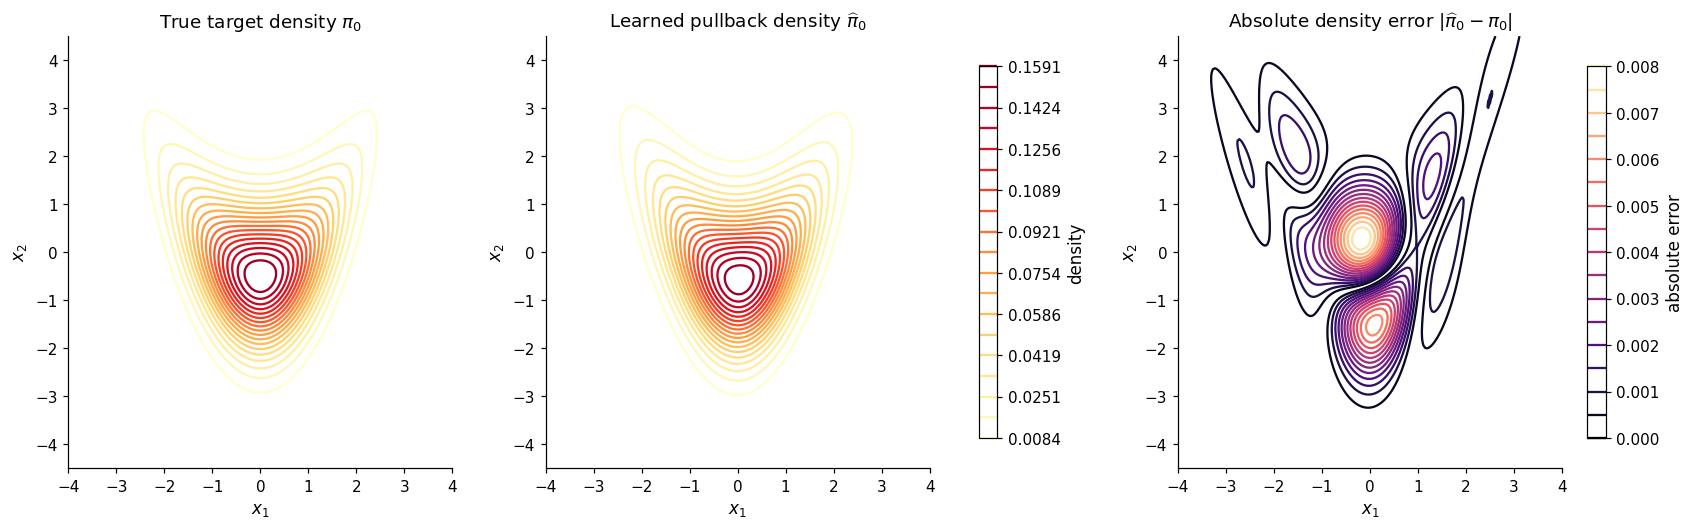

In [9]:
learned_pi_0_logdensity = S_hat_SF.pullback_logpdf(x_grid)
learned_pi_0_density = S_hat_SF.pullback_pdf(x_grid).reshape(x_xx.shape)
assert np.all(np.isfinite(learned_pi_0_logdensity))
assert np.all(np.isfinite(learned_pi_0_density))
assert np.all(learned_pi_0_density >= 0.0)

absolute_density_error = np.abs(learned_pi_0_density - true_pi_0_density)
density_max = max(true_pi_0_density.max(), learned_pi_0_density.max())
density_levels = np.linspace(0.0, density_max, 20)[1:]
error_max = absolute_density_error.max()

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.7), constrained_layout=True)
true_plot = axes[0].contour(x_xx, x_yy, true_pi_0_density, levels=density_levels, cmap="YlOrRd")
axes[0].set_title(r"True target density $\pi_0$")
learned_plot = axes[1].contour(x_xx, x_yy, learned_pi_0_density, levels=density_levels, cmap="YlOrRd")
axes[1].set_title(r"Learned pullback density $\widehat\pi_0$")
error_plot = axes[2].contour(x_xx, x_yy, absolute_density_error, levels=18, cmap="magma", vmin=0.0, vmax=error_max)
axes[2].set_title(r"Absolute density error $|\widehat\pi_0-\pi_0|$")
for ax in axes:
    style_joint_axis(ax)
fig.colorbar(true_plot, ax=axes[:2], shrink=0.86, label="density")
fig.colorbar(error_plot, ax=axes[2], shrink=0.86, label="absolute error")
plt.show()


## 9. Math-to-API summary

| Task | Mathematical operation | `TriangularMap` call |
| --- | --- | --- |
| Push target samples to reference | $\widehat{\boldsymbol{S}}^{\mathrm{SF}}(x)$ | `evaluate(x)` |
| Pull reference samples to target | $(\widehat{\boldsymbol{S}}^{\mathrm{SF}})^{-1}(z)$ | `inverse(z)` |
| Draw unconditional target samples | $z\sim\eta$, then $(\widehat{\boldsymbol{S}}^{\mathrm{SF}})^{-1}(z)$ | `sample(n, random_state=...)` |
| Draw $X_2\mid X_1=a$ | Clamp the leading coordinate while inverting | `conditional_sample(..., fixed_indices=[0], fixed_values=[a])` |
| Evaluate learned target density | $\widehat\pi_0(x)$ | `pullback_logpdf(x)` / `pullback_pdf(x)` |
| Evaluate learned conditional density | $\widehat\pi_0(x_2\mid x_1)$ | `conditional_pullback_logpdf(x, [0])` / `conditional_pullback_pdf(x, [0])` |

The total-order specification is the easiest starting point. Explicit multi-index sets are useful when you know a sparse structure, as in this banana example. In either case, triangularity makes both inversion-based sampling and leading-coordinate conditioning direct.